In [ ]:
import pandas as pd
import numpy as np
import networkx as nx

df = pd.read_csv("../../dataset/tnet_malawi_pilot.csv")
print("Taille brute :", df.shape)

print("Aperçu du CSV :")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")


df = df[df["contact_time"] > 0]

print("Après retrait contact_time = 0 :", df.shape)
print("Aperçu du CSV :")

df_agg = df.groupby(["id1", "id2"])["contact_time"].sum().reset_index()
df_agg.rename(columns={"contact_time": "weight"}, inplace=True)

print("Après agrégation :", df_agg.shape)
display(df.head())


G = nx.from_pandas_edgelist(df_agg, source="id1", target="id2")
Gw = nx.from_pandas_edgelist(df_agg, source="id1", target="id2", edge_attr="weight")
    
print("\n=========== GRAPHE FINAL (VERSION ARTICLE) ===========")
print("Nombre de nœuds :", G.number_of_nodes())
print("Nombre d'arêtes :", G.number_of_edges())


components = list(nx.connected_components(G))
print("\nLe graphe est connexe :", nx.is_connected(G))
print("Nombre de composantes :", len(components))
print("Taille de la composante géante :", len(max(components, key=len)))


Taille brute : (102293, 5)
Aperçu du CSV :
Après retrait contact_time = 0 : (102292, 4)
Aperçu du CSV :
Après agrégation : (347, 3)


,contact_time,day,id1,id2
1,40,22,79,9
2,40,22,4,84
3,40,22,31,37
4,60,22,79,9
5,80,22,79,9



=========== GRAPHE FINAL (VERSION ARTICLE) ===========
Nombre de nœuds : 86
Nombre d'arêtes : 347

Le graphe est connexe : False
Nombre de composantes : 2
Taille de la composante géante : 84


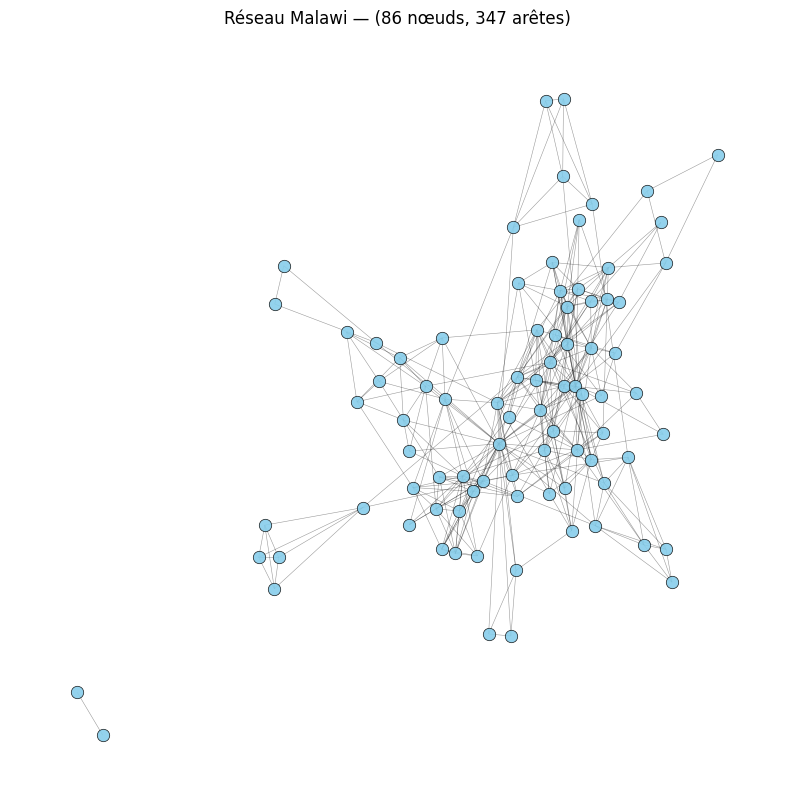

In [ ]:


import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G, seed=42, k=0.2)  


nx.draw_networkx_nodes(
    G,
    pos,
    node_size=80,
    node_color="skyblue",
    edgecolors="black",
    linewidths=0.5,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    width=0.4,
    alpha=0.4
)



plt.title("Réseau Malawi — (86 nœuds, 347 arêtes)")
plt.axis("off")
plt.show()


In [4]:

degrees = dict(G.degree())
deg_vals = np.array(list(degrees.values()))

print("Degré moyen :", deg_vals.mean())
print("Degré max :", deg_vals.max())
print("Coefficient de clustering :", nx.average_clustering(G))

components = list(nx.connected_components(G))


largest_cc = max(components, key=len)
G_gc = G.subgraph(largest_cc).copy()

print("Taille GC :", G_gc.number_of_nodes())

print("Distance moyenne :", nx.average_shortest_path_length(G_gc))
print("Diamètre :", nx.diameter(G_gc))


Degré moyen : 8.069767441860465
Degré max : 31
Coefficient de clustering : 0.5268929497437728
Taille GC : 84
Distance moyenne : 2.6153184165232357
Diamètre : 5


In [5]:
closeness  = nx.closeness_centrality(G_gc)
betweenness = nx.betweenness_centrality(G_gc, normalized=True)
eigenvector = nx.eigenvector_centrality_numpy(G_gc, weight="weight")
pagerank = nx.pagerank(G_gc, weight="weight")

centrality_df = pd.DataFrame({
    "closeness": closeness,
    "betweenness": betweenness,
    "eigenvector": eigenvector,
    "pagerank": pagerank
})

print("\nTop 5 betweenness :")
display(centrality_df.sort_values("betweenness", ascending=False).head())

print("\nTop 5 eigenvector :")
display(centrality_df.sort_values("eigenvector", ascending=False).head())

print("\nTop 5 pagerank :")
display(centrality_df.sort_values("pagerank", ascending=False).head())



Top 5 betweenness :


,closeness,betweenness,eigenvector,pagerank
16,0.584507,0.319733,0.257454,0.041260
81,0.538961,0.137126,0.310692,0.031684
74,0.506098,0.104789,0.233784,0.021109
28,0.367257,0.092963,0.030084,0.012325
1,0.494048,0.065521,0.182215,0.020922



Top 5 eigenvector :


,closeness,betweenness,eigenvector,pagerank
81,0.538961,0.137126,0.310692,0.031684
16,0.584507,0.319733,0.257454,0.041260
74,0.506098,0.104789,0.233784,0.021109
70,0.439153,0.021565,0.223744,0.019173
33,0.482558,0.026500,0.216434,0.016943



Top 5 pagerank :


,closeness,betweenness,eigenvector,pagerank
16,0.584507,0.319733,0.257454,0.041260
81,0.538961,0.137126,0.310692,0.031684
69,0.451087,0.041785,0.144373,0.023070
74,0.506098,0.104789,0.233784,0.021109
1,0.494048,0.065521,0.182215,0.020922


In [ ]:
import community as community_louvain


#  Métriques du réseau réel

N = G.number_of_nodes()
M = G.number_of_edges()

real_clustering = nx.average_clustering(G)

real_deg = np.array([d for _, d in G.degree()])
real_deg_var = real_deg.var()

real_assort = nx.degree_assortativity_coefficient(G)

G_gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
real_avg_path = nx.average_shortest_path_length(G_gc)

# Modularity Louvain sur le réseau réel
partition_real = community_louvain.best_partition(G, weight="weight")
real_mod = community_louvain.modularity(partition_real, G, weight="weight")

print("Réseau réel :")
print("  N =", N, "| M =", M)
print("  Clustering moyen        :", real_clustering)
print("  Distance moyenne (GC)   :", real_avg_path)
print("  Variance des degrés     :", real_deg_var)
print("  Assortativité de degré  :", real_assort)
print("  Modularity (Louvain)    :", real_mod)



def compute_metrics(G_in):

    c = nx.average_clustering(G_in)
    # GC
    comps = list(nx.connected_components(G_in))
    Gc = G_in.subgraph(max(comps, key=len)).copy()
    # Distance moyenne sur GC
    L = nx.average_shortest_path_length(Gc)
    # Variance des degrés
    degs = np.array([d for _, d in G_in.degree()])
    var_deg = degs.var()
    # Assortativité de degré
    assort = nx.degree_assortativity_coefficient(G_in)
    # Modularity Louvain
    part = community_louvain.best_partition(G_in, weight="weight")
    mod = community_louvain.modularity(part, G_in, weight="weight")
    return c, L, var_deg, assort, mod


NUM_RUNS = 10  # nombre de réalisations par modèle

# Erdos–Rényi G(n, m) 
clust_ER, L_ER, var_ER, assort_ER, mod_ER = [], [], [], [], []

for seed in range(NUM_RUNS):
    ER = nx.gnm_random_graph(N, M, seed=seed)
    c, L, v, a, m = compute_metrics(ER)
    clust_ER.append(c)
    L_ER.append(L)
    var_ER.append(v)
    assort_ER.append(a)
    mod_ER.append(m)

print("\nModèle Erdos–Rényi (moyenne ± écart-type,", NUM_RUNS, "réalisations) :")
print("  Clustering moyen        : {:.4f} ± {:.4f}".format(np.mean(clust_ER), np.std(clust_ER)))
print("  Distance moyenne (GC)   : {:.4f} ± {:.4f}".format(np.mean(L_ER), np.std(L_ER)))
print("  Variance des degrés     : {:.4f} ± {:.4f}".format(np.mean(var_ER), np.std(var_ER)))
print("  Assortativité de degré  : {:.4f} ± {:.4f}".format(np.mean(assort_ER), np.std(assort_ER)))
print("  Modularity (Louvain)    : {:.4f} ± {:.4f}".format(np.mean(mod_ER), np.std(mod_ER)))


# Configuration Model 
deg_seq = [d for _, d in G.degree()]  # séquence des degrés du réseau réel

clust_CM, L_CM, var_CM, assort_CM, mod_CM = [], [], [], [], []

for seed in range(NUM_RUNS):
    CM_multi = nx.configuration_model(deg_seq, seed=seed)
    # conversion en graphe simple sans multi-arêtes ni boucles
    CM = nx.Graph(CM_multi)
    CM.remove_edges_from(nx.selfloop_edges(CM))
    c, L, v, a, m = compute_metrics(CM)
    clust_CM.append(c)
    L_CM.append(L)
    var_CM.append(v)
    assort_CM.append(a)
    mod_CM.append(m)

print("\nModèle Configuration (moyenne ± écart-type,", NUM_RUNS, "réalisations) :")
print("  Clustering moyen        : {:.4f} ± {:.4f}".format(np.mean(clust_CM), np.std(clust_CM)))
print("  Distance moyenne (GC)   : {:.4f} ± {:.4f}".format(np.mean(L_CM), np.std(L_CM)))
print("  Variance des degrés     : {:.4f} ± {:.4f}".format(np.mean(var_CM), np.std(var_CM)))
print("  Assortativité de degré  : {:.4f} ± {:.4f}".format(np.mean(assort_CM), np.std(assort_CM)))
print("  Modularity (Louvain)    : {:.4f} ± {:.4f}".format(np.mean(mod_CM), np.std(mod_CM)))




Réseau réel :
  N = 86 | M = 347
  Clustering moyen        : 0.5268929497437728
  Distance moyenne (GC)   : 2.6153184165232357
  Variance des degrés     : 26.134667387777178
  Assortativité de degré  : 0.03625990752158057
  Modularity (Louvain)    : 0.5109667881968956

Modèle Erdos–Rényi (moyenne ± écart-type, 10 réalisations) :
  Clustering moyen        : 0.0976 ± 0.0094
  Distance moyenne (GC)   : 2.3389 ± 0.0049
  Variance des degrés     : 7.2719 ± 0.5997
  Assortativité de degré  : -0.0002 ± 0.0347
  Modularity (Louvain)    : 0.2922 ± 0.0108

Modèle Configuration (moyenne ± écart-type, 10 réalisations) :
  Clustering moyen        : 0.1299 ± 0.0187
  Distance moyenne (GC)   : 2.4344 ± 0.0232
  Variance des degrés     : 18.1454 ± 1.3434
  Assortativité de degré  : -0.0583 ± 0.0377
  Modularity (Louvain)    : 0.2956 ± 0.0110


In [14]:

import random
def random_walk(G, start, steps=1500):
    cur = start
    visits = []
    for _ in range(steps):
        visits.append(cur)
        neighs = list(G.neighbors(cur))
        if neighs:
            cur = random.choice(neighs)
        else:
            break
    return pd.Series(visits).value_counts(normalize=True)

start_node = random.choice(list(G_gc.nodes()))
rw_freq = random_walk(G_gc, start_node)

print("Nœud de départ :", start_node)
print("\nTop 10 visites random walk :")
print(rw_freq.head(10))

# ANALYSE TEMPOREL

print("\n=== Analyse 7 : Analyses temporelles ===")

SECONDS = 24*3600
df["hour"] = (df["contact_time"] % SECONDS) // 3600

# Contacts par heure
hour_counts = df.groupby("hour")["contact_time"].count()
print("\nContacts par heure :")
print(hour_counts)

# Contacts par jour
day_counts = df.groupby("day")["contact_time"].count()
print("\nContacts par jour :")
print(day_counts)


Nœud de départ : 58

Top 10 visites random walk :
16    0.055333
81    0.041333
69    0.036000
71    0.027333
1     0.024667
79    0.024000
2     0.023333
64    0.022000
74    0.022000
86    0.021333
Name: proportion, dtype: float64

=== Analyse 7 : Analyses temporelles ===

Contacts par heure :
hour
0     5774
1     7268
2     7353
3     6328
4     5878
5     5495
6     6354
7     7315
8     6023
9     2493
10    1701
11    1645
12    1852
13    1305
14    1325
15    1632
16    1241
17    2216
18    3799
19    4709
20    5576
21    5018
22    4781
23    5211
Name: contact_time, dtype: int64

Contacts par jour :
day
1     6766
2     7767
3     6549
4     7074
22    5983
23    8597
24    8326
25    6998
26    7961
27    5381
28    6058
29    5713
30    9217
31    9902
Name: contact_time, dtype: int64


In [ ]:
# Méthodes basées sur des marches aléatoires
# INFOMAP 
from infomap import Infomap
import igraph as ig


im = Infomap()

# ajouter liens
for u, v in G.edges():
    im.add_link(u, v)

im.run()

# récupérer les communautés
infomap_assign = {
    node.node_id: node.module_id
    for node in im.iterTree()
    if node.isLeaf()
}

infomap_k = len(set(infomap_assign.values()))

print("\n===== INFOMAP =====")
print("Nombre de communautés :", infomap_k)

# tailles des communautés
sizes = {}
for n, c in infomap_assign.items():
    sizes[c] = sizes.get(c, 0) + 1

print("Tailles :", list(sizes.values()))

# 3. WALKTRAP 

# Conversion
g_ig = ig.Graph.TupleList(G.edges(), directed=False)

walktrap = g_ig.community_walktrap().as_clustering()
walk_sizes = walktrap.sizes()

print("\n===== WALKTRAP =====")
print("Nombre de communautés :", len(walk_sizes))
print("Tailles :", walk_sizes)




===== INFOMAP =====
Nombre de communautés : 10
Tailles : [37, 13, 8, 4, 6, 5, 5, 3, 3, 2]

===== WALKTRAP =====
Nombre de communautés : 11
Tailles : [17, 3, 22, 3, 12, 6, 5, 8, 5, 3, 2]
  Infomap v2.8.0 starts at 2025-12-17 21:42:23
  -> Input network: 
  -> No file output!
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 86 nodes and 347 links...
  -> One-level codelength: 6.17156003

Trial 1/1 starting at 2025-12-17 21:42:23
Two-level compression: 14% 0.44% 
Partitioned to codelength 0.523589729 + 4.73822753 = 5.261817255 in 10 modules.
Super-level compression: to codelength 5.261817255 in 10 top modules.

Recursive sub-structure compression: 0% . Found 2 levels with codelength 5.261817255

=> Trial 1/1 finished in 0.002044167s with codelength 5.26181725


Summary after 1 trial
Best end mod


Spectral Clustering : 8 communautés
Tailles des communautés : [41, 21, 6, 5, 5, 3, 3, 2]

10 plus petites valeurs propres du Laplacien normalisé :
[-0.000000, 0.000000, 0.067425, 0.132788, 0.147327, 0.184823, 0.232372, 0.298524, 0.312749, 0.331314]


/Users/mariaboubekeur/miniconda3/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


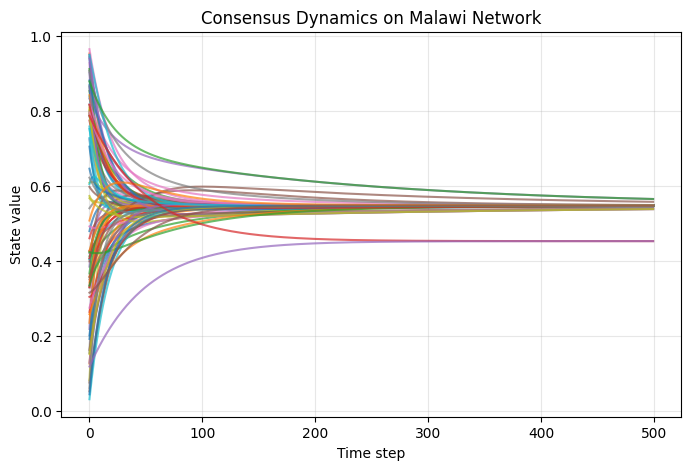

In [ ]:
#  Spectral Clustering + Laplacien + Consensus

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering


A = nx.to_numpy_array(G)   # matrice d’adjacence

k_spec = 8 # même nb de com. que Louvain non pondéré

spec = SpectralClustering(
    n_clusters=k_spec,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42          
)

labels = spec.fit_predict(A)
spec_sizes = pd.Series(labels).value_counts().tolist()

print("\nSpectral Clustering :", k_spec, "communautés")
print("Tailles des communautés :", spec_sizes)



#  CALCUL DU SPECTRE DU LAPLACIEN NORMALISÉ

nodes = list(G.nodes())  

L_norm = nx.normalized_laplacian_matrix(G, nodelist=nodes).astype(float).todense()
eigenvalues = np.linalg.eigvals(L_norm)
eigenvalues = np.sort(np.real(eigenvalues))   # valeurs propres triées


formatted = ", ".join([f"{val:.6f}" for val in eigenvalues[:10]])

print("\n10 plus petites valeurs propres du Laplacien normalisé :")
print(f"[{formatted}]")


#  LAPLACIEN NON NORMALISÉ POUR LA DYNAMIQUE DE CONSENSUS

L = nx.laplacian_matrix(G, nodelist=nodes).astype(float).todense()
L = np.array(L)


# SIMULATION DE LA DYNAMIQUE DE CONSENSUS 


n = len(nodes)
x = np.random.rand(n)  # état initial aléatoire

dt = 0.01
steps = 500

X = np.zeros((steps, n))

for t in range(steps):
    x = x - dt * (L @ x)
    X[t] = x



plt.figure(figsize=(8, 5))
plt.plot(X, alpha=0.7)
plt.title("Consensus Dynamics on Malawi Network")
plt.xlabel("Time step")
plt.ylabel("State value")
plt.grid(alpha=0.3)
plt.show()



=== K-CORE DECOMPOSITION ===
Analyse effectuée sur la LCC : 84 nœuds (sur 86 dans le graphe complet).

K-core maximal = 7
Taille du noyau (core) : 31


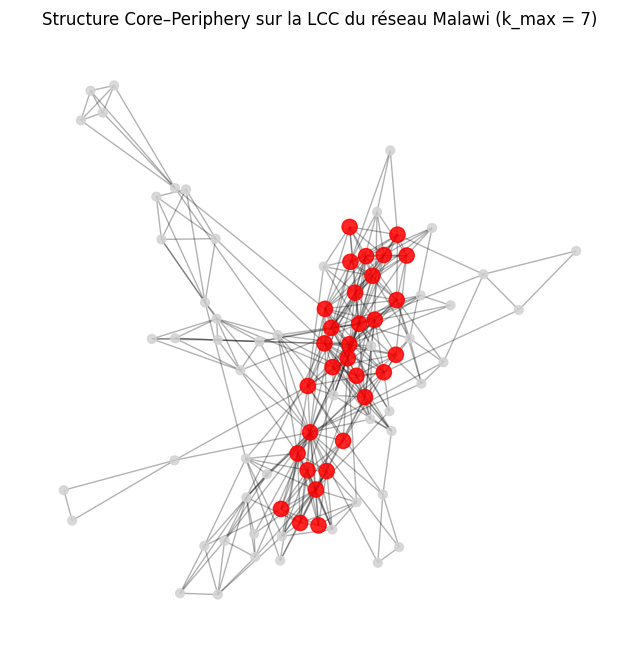

In [18]:
# K-core decomposition sur la plus grande composante connexe

print("\n=== K-CORE DECOMPOSITION ===")

largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

print(f"Analyse effectuée sur la LCC : {G_lcc.number_of_nodes()} nœuds "
      f"(sur {G.number_of_nodes()} dans le graphe complet).")


core_numbers = nx.core_number(G_lcc)
k_max = max(core_numbers.values())

core_nodes = [n for n, c in core_numbers.items() if c == k_max]



print(f"\nK-core maximal = {k_max}")
print(f"Taille du noyau (core) : {len(core_nodes)}")


colors = ["red" if core_numbers[n] == k_max else "lightgray" for n in G_lcc.nodes()]
sizes  = [120 if core_numbers[n] == k_max else 40 for n in G_lcc.nodes()]

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G_lcc, seed=42)

nx.draw_networkx_nodes(G_lcc, pos, node_size=sizes, node_color=colors, alpha=0.85)
nx.draw_networkx_edges(G_lcc, pos, alpha=0.3)

plt.title(f"Structure Core–Periphery sur la LCC du réseau Malawi (k_max = {k_max})")
plt.axis("off")
plt.show()


In [19]:
import networkx as nx
import numpy as np


largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

print(f"LCC : {G_lcc.number_of_nodes()} nœuds sur {G.number_of_nodes()}")

# Persistence probability 

def persistence_probability(G, S):
    S = set(S)
    deg = dict(G.degree())
    vol = sum(deg.values())

    # distribution stationnaire
    p = {i: deg[i] / vol for i in G.nodes()}

    alpha_num = 0
    alpha_den = sum(p[i] for i in S)

    for i in S:
        for j in G.neighbors(i):
            if j in S:
                alpha_num += p[i] * (1 / deg[i])

    return alpha_num / alpha_den if alpha_den > 0 else 0




def greedy_core_periphery(G):
    nodes = list(G.nodes())
    deg = dict(G.degree())

    # initialisation : nœud de degré minimal
    S = [min(nodes, key=lambda x: deg[x])]
    remaining = set(nodes) - set(S)

    coreness = {n: None for n in nodes}
    coreness[S[0]] = persistence_probability(G, S)

    while remaining:
        best_alpha = float("inf")
        best_node = None

        for v in remaining:
            alpha = persistence_probability(G, S + [v])
            if alpha < best_alpha:
                best_alpha = alpha
                best_node = v

        S.append(best_node)
        coreness[best_node] = best_alpha
        remaining.remove(best_node)

    return S, coreness


# calcul de la coreness

order, coreness = greedy_core_periphery(G_lcc)



#  variation de α

alphas = np.linspace(0, 1, 11)

print("\nDynamique d’absorption de la périphérie :")

for alpha in alphas:
    periphery = [v for v, a in coreness.items() if a <= alpha]
    print(f"α = {alpha:.2f}  →  taille périphérie = {len(periphery)}")

# case : extraction pour un α donné

alpha = 0.1
core = [v for v, a in coreness.items() if a > alpha]
periphery = [v for v, a in coreness.items() if a <= alpha]

print("\n=== Core–Periphery pour α =", alpha, "===")
print("Core :", len(core))
print("Periphery :", len(periphery))


LCC : 84 nœuds sur 86

Dynamique d’absorption de la périphérie :
α = 0.00  →  taille périphérie = 19
α = 0.10  →  taille périphérie = 28
α = 0.20  →  taille périphérie = 38
α = 0.30  →  taille périphérie = 47
α = 0.40  →  taille périphérie = 54
α = 0.50  →  taille périphérie = 61
α = 0.60  →  taille périphérie = 67
α = 0.70  →  taille périphérie = 72
α = 0.80  →  taille périphérie = 77
α = 0.90  →  taille périphérie = 81
α = 1.00  →  taille périphérie = 84

=== Core–Periphery pour α = 0.1 ===
Core : 56
Periphery : 28


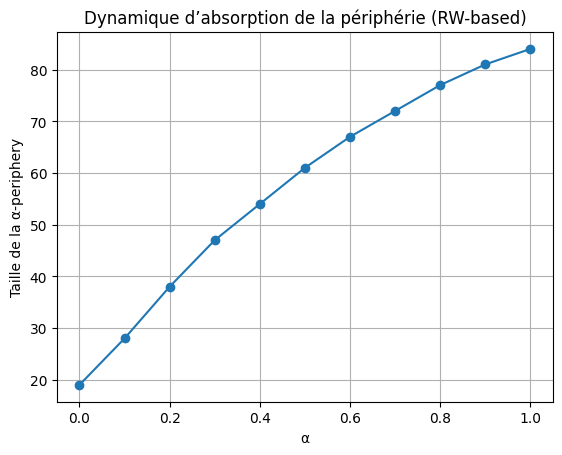

In [20]:
import matplotlib.pyplot as plt
import numpy as np

alphas = np.linspace(0, 1, 11)
periphery_sizes = []

for alpha in alphas:
    periphery = [v for v, a in coreness.items() if a <= alpha]
    periphery_sizes.append(len(periphery))

plt.figure()
plt.plot(alphas, periphery_sizes, marker='o')
plt.xlabel("α")
plt.ylabel("Taille de la α-periphery")
plt.title("Dynamique d’absorption de la périphérie (RW-based)")
plt.grid(True)
plt.show()



Plus grande valeur propre λ_max = 11.9348
Seuil épidémique théorique β/μ > 1/λ_max = 0.0838

Taille composante géante : 84 nœuds

Top 10 superspreaders (GC only) :
    node  degree  eigenvector  stationary
38    16      31     0.257454    0.044798
29    81      26     0.310692    0.037572
14    69      18     0.144373    0.026012
17    74      17     0.233784    0.024566
16    70      16     0.223744    0.023121
0      1      16     0.182215    0.023121
20    52      15     0.204488    0.021676
79    63      15     0.213809    0.021676
9     86      15     0.137245    0.021676
4     33      14     0.216434    0.020231

Superspreader choisi : 16
Nœud périphérique choisi : 67


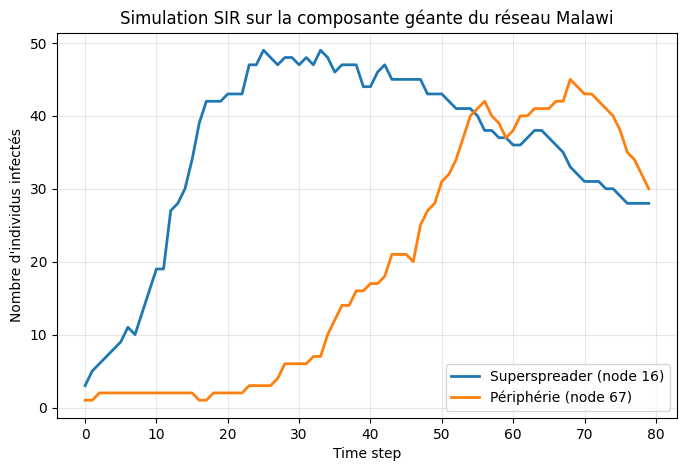

In [ ]:
#  ÉPIDÉMIES SUR RÉSEAUX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Calcul du plus grand λ_max 

A = nx.to_numpy_array(G)     
eigs = np.linalg.eigvals(A)
lambda_max = np.max(np.real(eigs))

print(f"\nPlus grande valeur propre λ_max = {lambda_max:.4f}")
print(f"Seuil épidémique théorique β/μ > 1/λ_max = {1/lambda_max:.4f}")


# Identification des superspreaders

giant = max(nx.connected_components(G), key=len)
G_gc = G.subgraph(giant).copy()

print(f"\nTaille composante géante : {len(G_gc.nodes())} nœuds")

deg_cent = dict(G_gc.degree())
eig_cent = nx.eigenvector_centrality_numpy(G_gc)
rw_stat = {n: deg_cent[n] / sum(deg_cent.values()) for n in G_gc.nodes()}

df_sup = pd.DataFrame({
    "node": list(G_gc.nodes()),
    "degree": [deg_cent[n] for n in G_gc.nodes()],
    "eigenvector": [eig_cent[n] for n in G_gc.nodes()],
    "stationary": [rw_stat[n] for n in G_gc.nodes()]
}).sort_values(by="stationary", ascending=False)

print("\nTop 10 superspreaders (GC only) :")
print(df_sup.head(10))

super_node = int(df_sup.iloc[0]["node"])
periph_node = int(df_sup.iloc[-1]["node"])

print(f"\nSuperspreader choisi : {super_node}")
print(f"Nœud périphérique choisi : {periph_node}")


# Simulation SIR 

def run_SIR(G, patient_zero, beta=0.03, mu=0.02, steps=80):
    """Simule un processus SIR sur un graphe donné."""
    status = {n: "S" for n in G.nodes()}
    status[patient_zero] = "I"

    infected_counts = []

    for _ in range(steps):
        new_status = status.copy()

        for n in G.nodes():
            if status[n] == "I":

                # guérison
                if np.random.rand() < mu:
                    new_status[n] = "R"

                # infection des voisins
                for neigh in G.neighbors(n):
                    if status[neigh] == "S" and np.random.rand() < beta:
                        new_status[neigh] = "I"

        status = new_status
        infected_counts.append(sum(1 for v in status.values() if v == "I"))

    return infected_counts


I_super = run_SIR(G_gc, super_node)
I_periph = run_SIR(G_gc, periph_node)


#  Visualisation

plt.figure(figsize=(8,5))
plt.plot(I_super, label=f"Superspreader (node {super_node})", linewidth=2)
plt.plot(I_periph, label=f"Périphérie (node {periph_node})", linewidth=2)
plt.xlabel("Time step")
plt.ylabel("Nombre d'individus infectés")
plt.title("Simulation SIR sur la composante géante du réseau Malawi")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
